# NLP Final Project — Banking Intent Classification
**Dataset:** BANKING77 (PolyAI) — 13,083 muestras, 77 clases de intención bancaria  
**Task:** Clasificar la intención de consultas de clientes (equivalente a transcripciones de llamadas)  

---
**Secciones:**
1. EDA & Preprocessing
2. Traditional ML (LR, SVM, Random Forest)
3. Deep Learning — Bidirectional LSTM
4. Deep Learning — DistilBERT
5. Comparación de resultados

In [34]:
import os, sys
sys.path.insert(0, '.')
os.makedirs('data', exist_ok=True)
os.makedirs('results/figures', exist_ok=True)
print('Ready.')

Ready.


---
## SECCIÓN 1 — EDA & Preprocessing
Carga BANKING77 de HuggingFace, genera figuras de EDA y guarda los CSVs limpios en `data/`.

In [35]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
STOP_WORDS = set(stopwords.words('english'))

print('Imports OK')

Imports OK


In [36]:
# Cargar dataset desde el repositorio oficial de PolyAI (GitHub)
# (datasets v4+ ya no soporta loading scripts, cargamos los CSV directamente)
import urllib.request, io

BASE = 'https://raw.githubusercontent.com/PolyAI-LDN/task-specific-datasets/master/banking_data'

with urllib.request.urlopen(f'{BASE}/train.csv', timeout=30) as r:
    train_df = pd.read_csv(io.StringIO(r.read().decode('utf-8')))
with urllib.request.urlopen(f'{BASE}/test.csv', timeout=30) as r:
    test_df = pd.read_csv(io.StringIO(r.read().decode('utf-8')))

# Construir mapping nombre → id numérico (ordenado para reproducibilidad)
label_names = sorted(train_df['category'].unique().tolist())
label2id    = {v: i for i, v in enumerate(label_names)}

for df in [train_df, test_df]:
    df['label']  = df['category'].map(label2id)
    df['intent'] = df['category']

print(f'Train: {len(train_df):,} | Test: {len(test_df):,} | Clases: {len(label_names)}')
train_df.head()

Train: 10,003 | Test: 3,080 | Clases: 77


,text,category,label,intent
0,I am still waiting on my card?,card_arrival,12,card_arrival
1,What can I do if my card still hasn't arrived ...,card_arrival,12,card_arrival
2,I have been waiting over a week. Is the card s...,card_arrival,12,card_arrival
3,Can I track my card while it is in the process...,card_arrival,12,card_arrival
4,"How do I know if I will get my card, or if it ...",card_arrival,12,card_arrival


Muestras por clase — Min: 35  Max: 187  Media: 129.9


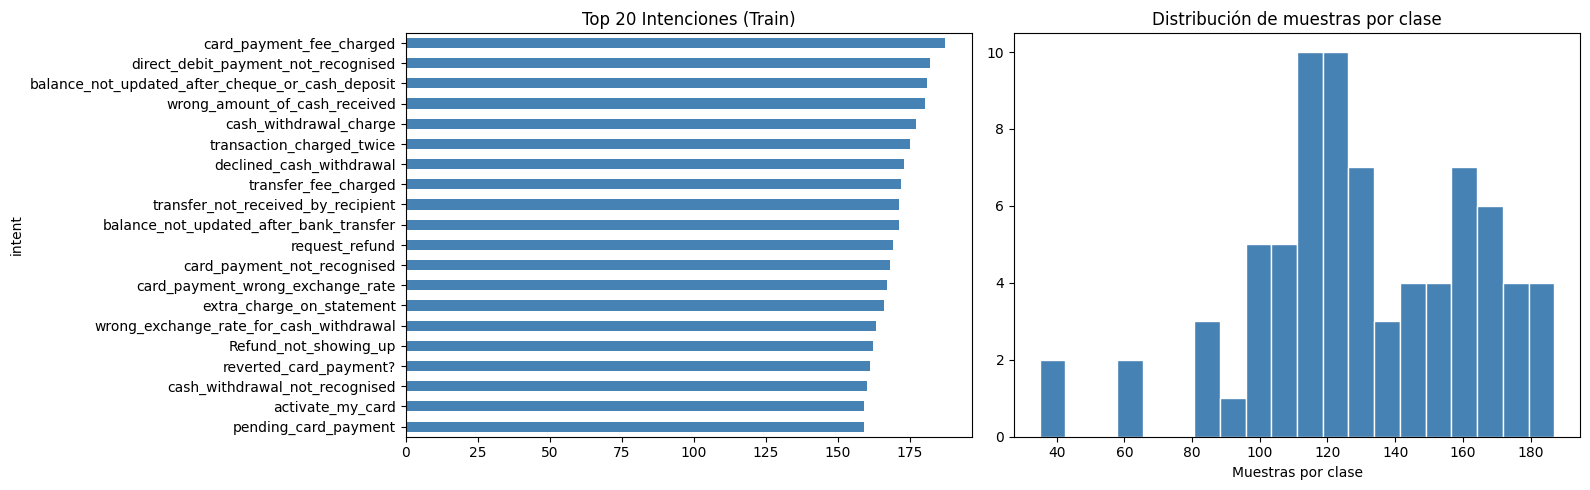

In [37]:
# Distribución de clases
counts = train_df['intent'].value_counts()
print(f'Muestras por clase — Min: {counts.min()}  Max: {counts.max()}  Media: {counts.mean():.1f}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
counts.head(20).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 20 Intenciones (Train)')
axes[0].invert_yaxis()
axes[1].hist(counts.values, bins=20, color='steelblue', edgecolor='white')
axes[1].set_title('Distribución de muestras por clase')
axes[1].set_xlabel('Muestras por clase')
plt.tight_layout()
plt.savefig('results/figures/eda_class_distribution.png', dpi=150)
plt.show()

In [38]:
# Ejemplos por intención
sample_intents = ['card_not_working', 'balance_not_updated_after_bank_transfer',
                  'cancel_transfer', 'wrong_exchange_rate_for_cash_withdrawal']
for intent in sample_intents:
    examples = train_df[train_df['intent'] == intent]['text'].head(2).tolist()
    print(f"\n[{intent}]")
    for e in examples:
        print(f"  · {e}")


[card_not_working]
  · I can't use my card because it is not working.
  · I can't seem to be able to use my card

[balance_not_updated_after_bank_transfer]
  · help my money isnt showing up
  · how do i see what i transferred

[cancel_transfer]
  · Cancel a transaction
  · Am I able to cancel a transfer I just made

[wrong_exchange_rate_for_cash_withdrawal]
  · The wrong exchange rate was applied to me while pulling out cash.
  · I got less cash because of the exchange rate.


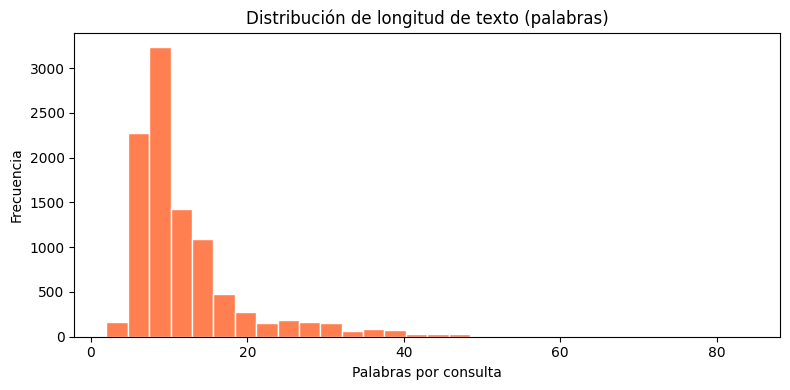

Longitud media: 12.2 palabras
Longitud máx: 84 palabras


In [39]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_df['text_clean'] = train_df['text'].apply(clean_text)
test_df['text_clean']  = test_df['text'].apply(clean_text)
train_df['text_len']   = train_df['text_clean'].str.split().str.len()

# Distribución de longitud de texto
plt.figure(figsize=(8, 4))
plt.hist(train_df['text_len'], bins=30, color='coral', edgecolor='white')
plt.title('Distribución de longitud de texto (palabras)')
plt.xlabel('Palabras por consulta')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.savefig('results/figures/eda_text_lengths.png', dpi=150)
plt.show()

print(f'Longitud media: {train_df["text_len"].mean():.1f} palabras')
print(f'Longitud máx: {train_df["text_len"].max()} palabras')

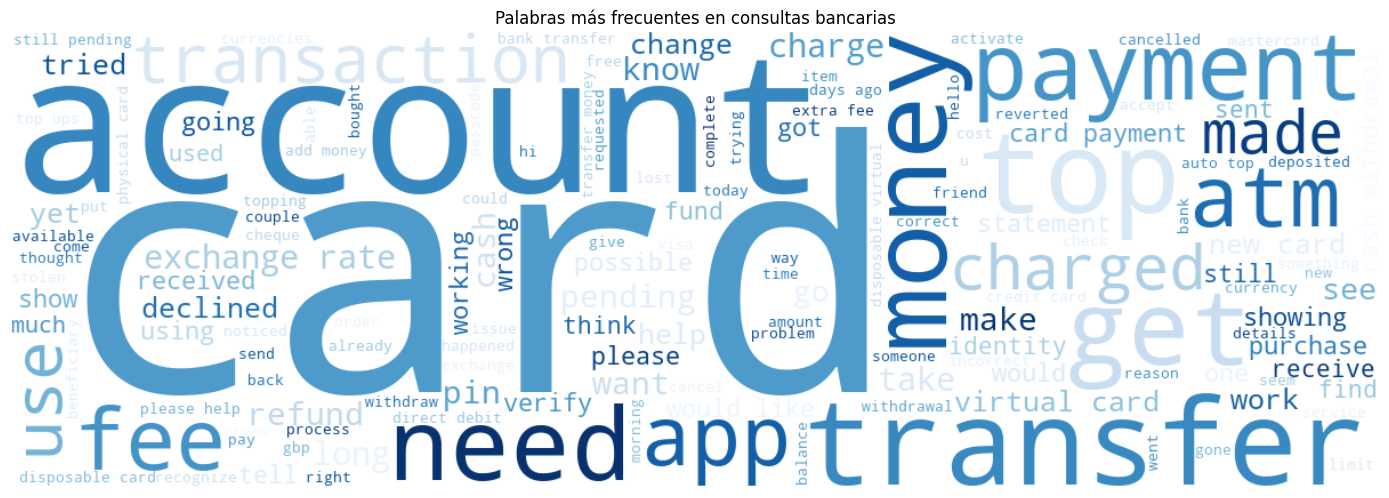

In [40]:
# Wordcloud
try:
    from wordcloud import WordCloud
    all_text = ' '.join(train_df['text_clean'].tolist())
    wc = WordCloud(width=1200, height=400, background_color='white',
                   colormap='Blues', max_words=150, stopwords=STOP_WORDS).generate(all_text)
    plt.figure(figsize=(14, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title('Palabras más frecuentes en consultas bancarias')
    plt.tight_layout()
    plt.savefig('results/figures/eda_wordcloud.png', dpi=150, bbox_inches='tight')
    plt.show()
except ImportError:
    print('wordcloud no instalado. pip install wordcloud')

In [41]:
# Guardar CSVs y label_names
train_df.to_csv('data/train.csv', index=False)
test_df.to_csv('data/test.csv', index=False)
with open('data/label_names.json', 'w') as f:
    json.dump(label_names, f)

print('Guardado: data/train.csv')
print('Guardado: data/test.csv')
print('Guardado: data/label_names.json')

Guardado: data/train.csv
Guardado: data/test.csv
Guardado: data/label_names.json


---
## SECCIÓN 2 — Traditional ML con TF-IDF
Requiere haber corrido la Sección 1 (o tener `data/train.csv` y `data/test.csv`).

In [42]:
import pandas as pd
import json
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, classification_report)
train_df    = pd.read_csv('data/train.csv')
test_df     = pd.read_csv('data/test.csv')
with open('data/label_names.json') as f:
    label_names = json.load(f)

X_train = train_df['text_clean'].fillna('').tolist()
X_test  = test_df['text_clean'].fillna('').tolist()
y_train = train_df['label'].tolist()
y_test  = test_df['label'].tolist()

def make_tfidf():
    return TfidfVectorizer(ngram_range=(1, 2), max_features=30_000, sublinear_tf=True)

def report_metrics(y_true, y_pred, model_name):
    m = {
        'model':       model_name,
        'accuracy':    round(accuracy_score(y_true, y_pred), 4),
        'precision':   round(precision_score(y_true, y_pred, average='macro', zero_division=0), 4),
        'recall':      round(recall_score(y_true, y_pred, average='macro', zero_division=0), 4),
        'f1_macro':    round(f1_score(y_true, y_pred, average='macro', zero_division=0), 4),
        'f1_weighted': round(f1_score(y_true, y_pred, average='weighted', zero_division=0), 4),
    }
    print(f"\n{'='*40}")
    print(f"  {model_name}")
    print(f"{'='*40}")
    for k, v in m.items():
        if k != 'model':
            print(f"  {k:<15}: {v:.4f}")
    return m

ml_results = []
print('Datos cargados OK')

Datos cargados OK


In [43]:
# ── Logistic Regression ──────────────────────────────────────────────────────
print('Entrenando Logistic Regression...')
pipe_lr = Pipeline([
    ('tfidf', make_tfidf()),
    ('clf',   LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs',
                                  multi_class='multinomial', random_state=42, n_jobs=-1))
])
pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)
ml_results.append(report_metrics(y_test, y_pred_lr, 'Logistic Regression'))

Entrenando Logistic Regression...


/Users/leogame/Documents/Maestria/Trimestre_3/NLP/Proyecto_Final/venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



  Logistic Regression
  accuracy       : 0.8555
  precision      : 0.8667
  recall         : 0.8555
  f1_macro       : 0.8540
  f1_weighted    : 0.8540


In [44]:
# ── SVM (LinearSVC) ──────────────────────────────────────────────────────────
print('Entrenando SVM (LinearSVC)...')
pipe_svm = Pipeline([
    ('tfidf', make_tfidf()),
    ('clf',   LinearSVC(C=1.0, max_iter=3000, random_state=42))
])
pipe_svm.fit(X_train, y_train)
y_pred_svm = pipe_svm.predict(X_test)
ml_results.append(report_metrics(y_test, y_pred_svm, 'SVM (LinearSVC)'))

Entrenando SVM (LinearSVC)...

  SVM (LinearSVC)
  accuracy       : 0.8935
  precision      : 0.8976
  recall         : 0.8935
  f1_macro       : 0.8937
  f1_weighted    : 0.8937


In [45]:
# ── Random Forest ────────────────────────────────────────────────────────────
print('Entrenando Random Forest (puede tardar 2-3 min)...')
pipe_rf = Pipeline([
    ('tfidf', make_tfidf()),
    ('clf',   RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
])
pipe_rf.fit(X_train, y_train)
y_pred_rf = pipe_rf.predict(X_test)
ml_results.append(report_metrics(y_test, y_pred_rf, 'Random Forest'))

Entrenando Random Forest (puede tardar 2-3 min)...

  Random Forest
  accuracy       : 0.8656
  precision      : 0.8712
  recall         : 0.8656
  f1_macro       : 0.8652
  f1_weighted    : 0.8652


In [46]:
# Guardar resultados ML tradicional
with open('results/traditional_results.json', 'w') as f:
    json.dump(ml_results, f, indent=2)
print('Guardado: results/traditional_results.json')

# Tabla resumen
pd.DataFrame(ml_results).set_index('model')

Guardado: results/traditional_results.json


,accuracy,precision,recall,f1_macro,f1_weighted
model,,,,,
Logistic Regression,0.8555,0.8667,0.8555,0.8540,0.8540
SVM (LinearSVC),0.8935,0.8976,0.8935,0.8937,0.8937
Random Forest,0.8656,0.8712,0.8656,0.8652,0.8652


---
## SECCIÓN 3 — BiLSTM
Requiere haber corrido la Sección 1 (o tener `data/train.csv` y `data/test.csv`).

In [47]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from tqdm.notebook import tqdm
from collections import Counter

# Detectar dispositivo (CUDA en Colab, MPS en Mac, CPU como fallback)
DEVICE_LSTM = (torch.device('mps')  if torch.backends.mps.is_available() else
               torch.device('cpu'))
print(f'Device LSTM: {DEVICE_LSTM}')

Device LSTM: mps


In [48]:
train_df = pd.read_csv('data/train.csv')
test_df  = pd.read_csv('data/test.csv')

X_train_raw = train_df['text_clean'].fillna('').tolist()
X_test_raw  = test_df['text_clean'].fillna('').tolist()
y_train     = train_df['label'].tolist()
y_test      = test_df['label'].tolist()
print('Datos cargados OK')

Datos cargados OK


In [72]:
import urllib.request, zipfile, os
import numpy as np
from collections import Counter
 
MAX_LEN    = 40
EMBED_DIM  = 100   # GloVe tiene versiones de 50, 100, 200, 300d — usamos 100d
 
# ── 1. Descargar GloVe 6B 100d (822 MB zip, ~170MB el .txt) ──────────────────
GLOVE_DIR  = 'data/glove'
GLOVE_FILE = f'{GLOVE_DIR}/glove.6B.100d.txt'
GLOVE_URL  = 'https://nlp.stanford.edu/data/glove.6B.zip'
 
os.makedirs(GLOVE_DIR, exist_ok=True)
 
if not os.path.exists(GLOVE_FILE):
    print('Descargando GloVe 6B (puede tardar unos minutos)...')
    zip_path = f'{GLOVE_DIR}/glove.6B.zip'
    urllib.request.urlretrieve(GLOVE_URL, zip_path)
    print('Extrayendo...')
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extract('glove.6B.100d.txt', GLOVE_DIR)
    os.remove(zip_path)
    print(f'GloVe listo en {GLOVE_FILE}')
else:
    print(f'GloVe ya existe en {GLOVE_FILE}')

Descargando GloVe 6B (puede tardar unos minutos)...
Extrayendo...
GloVe listo en data/glove/glove.6B.100d.txt


In [73]:
print('Cargando vectores GloVe...')
glove_vectors = {}
with open(GLOVE_FILE, encoding='utf-8') as f:
    for line in f:
        parts = line.split()
        word  = parts[0]
        vec   = np.array(parts[1:], dtype=np.float32)
        glove_vectors[word] = vec
 
print(f'Vectores GloVe cargados: {len(glove_vectors):,} palabras')

Cargando vectores GloVe...
Vectores GloVe cargados: 400,000 palabras


In [74]:
counter = Counter()
for text in X_train_raw:
    counter.update(text.split())
 
# vocab: <PAD>=0, <OOV>=1, luego palabras por frecuencia
vocab = {'<PAD>': 0, '<OOV>': 1}
for word, _ in counter.most_common():
    if word not in vocab:
        vocab[word] = len(vocab)
 
VOCAB_SIZE = len(vocab)
print(f'Vocabulario del corpus: {VOCAB_SIZE:,} palabras únicas')

Vocabulario del corpus: 2,315 palabras únicas


In [75]:
embedding_matrix = np.zeros((VOCAB_SIZE + 1, EMBED_DIM), dtype=np.float32)
 
found, not_found = 0, 0
for word, idx in vocab.items():
    if word in glove_vectors:
        embedding_matrix[idx] = glove_vectors[word]
        found += 1
    else:
        # Palabras sin vector GloVe: inicialización aleatoria pequeña
        embedding_matrix[idx] = np.random.normal(scale=0.1, size=(EMBED_DIM,))
        not_found += 1
 
coverage = found / VOCAB_SIZE * 100
print(f'Cobertura GloVe: {found:,}/{VOCAB_SIZE:,} palabras ({coverage:.1f}%)')
print(f'Sin vector (random init): {not_found:,} palabras')

Cobertura GloVe: 2,243/2,315 palabras (96.9%)
Sin vector (random init): 72 palabras


In [77]:
def texts_to_sequences(texts, vocab, max_len):
    seqs = []
    for text in texts:
        ids  = [vocab.get(w, 1) for w in text.split()]  # 1 = <OOV>
        ids  = ids[:max_len]
        ids += [0] * (max_len - len(ids))               # 0 = <PAD>
        seqs.append(ids)
    return np.array(seqs, dtype=np.int64)
 
X_train_seq = texts_to_sequences(X_train_raw, vocab, MAX_LEN)
X_test_seq  = texts_to_sequences(X_test_raw,  vocab, MAX_LEN)
print(f'X_train shape: {X_train_seq.shape}')
print(f'X_test shape:  {X_test_seq.shape}')

X_train shape: (10003, 40)
X_test shape:  (3080, 40)


In [81]:
class Attention(nn.Module):
    """Atención aditiva sobre los estados ocultos del LSTM."""
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)
    def forward(self, x):
        scores  = self.attn(x).squeeze(-1)
        weights = torch.softmax(scores, dim=-1)
        return (x * weights.unsqueeze(-1)).sum(dim=1)

class BiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=100, lstm_units=256,
                 num_classes=77, dropout=0.4,
                 pretrained_embeddings=None):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size + 1, embed_dim, padding_idx=0)

        if pretrained_embeddings is not None:
            self.embedding.weight = nn.Parameter(
                torch.tensor(pretrained_embeddings, dtype=torch.float32)
            )
            self.embedding.weight.requires_grad = True

        self.spatial_drop = nn.Dropout(0.3)
        self.lstm1        = nn.LSTM(embed_dim, lstm_units, batch_first=True,
                                    bidirectional=True)
        self.drop_between = nn.Dropout(0.3)
        self.lstm2        = nn.LSTM(lstm_units * 2, lstm_units // 2, batch_first=True,
                                    bidirectional=True)
        lstm_out_dim      = lstm_units

        self.layer_norm   = nn.LayerNorm(lstm_out_dim)
        self.attention    = Attention(lstm_out_dim)
        self.fc1          = nn.Linear(lstm_out_dim, 256)
        self.fc2          = nn.Linear(256, num_classes)
        self.dropout2     = nn.Dropout(dropout)
        self.relu         = nn.ReLU()

    def forward(self, x):
        x = self.embedding(x)
        x = self.spatial_drop(x)
        x, _ = self.lstm1(x)
        x = self.drop_between(x)
        x, _ = self.lstm2(x)
        x = self.layer_norm(x)
        x = self.attention(x)
        x = self.relu(self.fc1(x))
        x = self.dropout2(x)
        return self.fc2(x)

In [82]:
lstm_model = BiLSTM(
       vocab_size        = VOCAB_SIZE,
       embed_dim         = EMBED_DIM,
       pretrained_embeddings = embedding_matrix
).to(DEVICE_LSTM)
total_params = sum(p.numel() for p in lstm_model.parameters() if p.requires_grad)
print(f'Parámetros entrenables: {total_params:,}')

Parámetros entrenables: 1,708,542


In [83]:
# AdamW con weight_decay=1e-4 (mejor regularización L2 desacoplada)
optimizer = torch.optim.AdamW(lstm_model.parameters(), lr=1e-3, weight_decay=1e-4)
# label_smoothing=0.1 ayuda a generalizar con 77 clases
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5,
                               patience=3, min_lr=1e-5)

class IntentDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]
 
val_size   = int(0.1 * len(X_train_seq))
train_size = len(X_train_seq) - val_size
train_ds, val_ds = torch.utils.data.random_split(
    IntentDataset(X_train_seq, y_train), [train_size, val_size]
)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=64)

In [84]:
EPOCHS   = 50
PATIENCE = 8
 
history = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}
best_val_loss    = float('inf')
patience_counter = 0
best_weights     = None
 
for epoch in range(EPOCHS):
    lstm_model.train()
    train_loss, train_correct, train_total = 0, 0, 0
    for X_batch, y_batch in tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS}'):
        X_batch, y_batch = X_batch.to(DEVICE_LSTM), y_batch.to(DEVICE_LSTM)
        optimizer.zero_grad()
        out  = lstm_model(X_batch)
        loss = criterion(out, y_batch)
        loss.backward()
        # CAMBIO 4: gradient clipping — estabiliza el entrenamiento del LSTM
        torch.nn.utils.clip_grad_norm_(lstm_model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss    += loss.item() * len(y_batch)
        train_correct += (out.argmax(1) == y_batch).sum().item()
        train_total   += len(y_batch)
 
    lstm_model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(DEVICE_LSTM), y_batch.to(DEVICE_LSTM)
            out  = lstm_model(X_batch)
            loss = criterion(out, y_batch)
            val_loss    += loss.item() * len(y_batch)
            val_correct += (out.argmax(1) == y_batch).sum().item()
            val_total   += len(y_batch)
 
    t_loss = train_loss / train_total
    t_acc  = train_correct / train_total
    v_loss = val_loss / val_total
    v_acc  = val_correct / val_total
 
    history['loss'].append(t_loss)
    history['accuracy'].append(t_acc)
    history['val_loss'].append(v_loss)
    history['val_accuracy'].append(v_acc)
 
    print(f'Epoch {epoch+1:2d}: loss={t_loss:.4f} acc={t_acc:.4f} | '
          f'val_loss={v_loss:.4f} val_acc={v_acc:.4f}')
 
    scheduler.step(v_loss)
 
    if v_loss < best_val_loss:
        best_val_loss    = v_loss
        best_weights     = {k: v.cpu().clone() for k, v in lstm_model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'Early stopping en época {epoch+1}')
            break
 
lstm_model.load_state_dict(best_weights)
lstm_model.to(DEVICE_LSTM)
print('Entrenamiento completo. Mejores pesos restaurados.')

Epoch 1/50:   0%|          | 0/141 [00:00<?, ?it/s]

Epoch  1: loss=3.8292 acc=0.1050 | val_loss=2.5933 val_acc=0.4050


Epoch 2/50:   0%|          | 0/141 [00:00<?, ?it/s]

Epoch  2: loss=2.2346 acc=0.5072 | val_loss=1.6743 val_acc=0.6970


Epoch 3/50:   0%|          | 0/141 [00:00<?, ?it/s]

...

Epoch 28: loss=0.8270 acc=0.9953 | val_loss=1.1127 val_acc=0.9040


Epoch 29/50:   0%|          | 0/141 [00:00<?, ?it/s]

Epoch 29: loss=0.8257 acc=0.9956 | val_loss=1.1115 val_acc=0.9010


Epoch 30/50:   0%|          | 0/141 [00:00<?, ?it/s]

Epoch 30: loss=0.8246 acc=0.9949 | val_loss=1.1132 val_acc=0.9090
Early stopping en época 30
Entrenamiento completo. Mejores pesos restaurados.


  accuracy       : 0.8994
  precision      : 0.9034
  recall         : 0.8994
  f1_macro       : 0.8994
  f1_weighted    : 0.8994


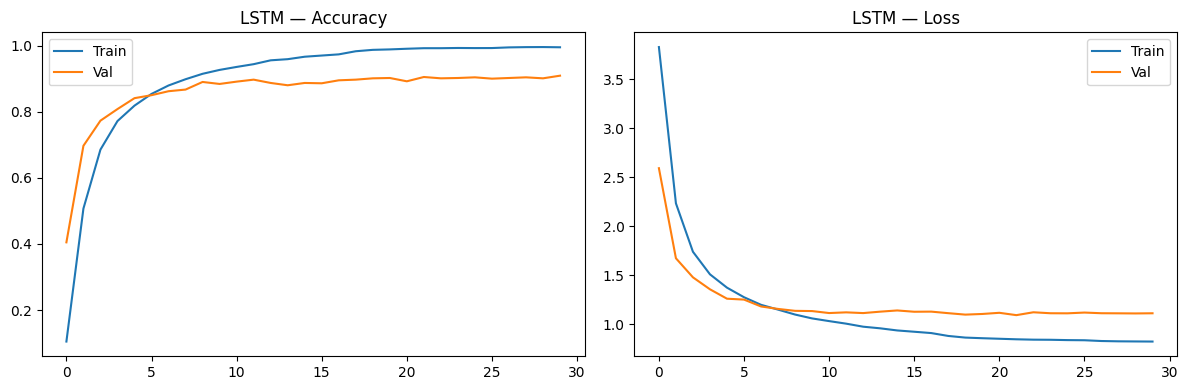

Guardado: results/lstm_results.json


In [85]:
# ── Evaluación ────────────────────────────────────────────────────────────────
import os
os.makedirs('results/figures', exist_ok=True)
lstm_model.eval()
test_ds     = IntentDataset(X_test_seq, y_test)
test_loader = DataLoader(test_ds, batch_size=64)
 
y_pred_lstm = []
with torch.no_grad():
    for X_batch, _ in test_loader:
        out = lstm_model(X_batch.to(DEVICE_LSTM))
        y_pred_lstm.extend(out.argmax(1).cpu().tolist())
 
lstm_metrics = {
    'model':       'Bidirectional LSTM',
    'accuracy':    round(accuracy_score(y_test, y_pred_lstm), 4),
    'precision':   round(precision_score(y_test, y_pred_lstm, average='macro', zero_division=0), 4),
    'recall':      round(recall_score(y_test, y_pred_lstm, average='macro', zero_division=0), 4),
    'f1_macro':    round(f1_score(y_test, y_pred_lstm, average='macro', zero_division=0), 4),
    'f1_weighted': round(f1_score(y_test, y_pred_lstm, average='weighted', zero_division=0), 4),
}
for k, v in lstm_metrics.items():
    if k != 'model': print(f'  {k:<15}: {v:.4f}')
 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['accuracy'],     label='Train')
axes[0].plot(history['val_accuracy'], label='Val')
axes[0].set_title('LSTM — Accuracy'); axes[0].legend()
axes[1].plot(history['loss'],     label='Train')
axes[1].plot(history['val_loss'], label='Val')
axes[1].set_title('LSTM — Loss'); axes[1].legend()
plt.tight_layout()
plt.savefig('results/figures/lstm_training_history.png', dpi=150)
plt.show()
 
with open('results/lstm_results.json', 'w') as f:
    json.dump([lstm_metrics], f, indent=2)
print('Guardado: results/lstm_results.json')

with open('results/lstm_history.json', 'w') as f:
    json.dump(history, f)

---
## SECCIÓN 4 — DistilBERT
Requiere haber corrido la Sección 1 (o tener `data/train.csv` y `data/test.csv`).

In [55]:
import torch
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from transformers import (DistilBertTokenizerFast,
                          DistilBertForSequenceClassification,
                          get_linear_schedule_with_warmup)
from torch.optim import AdamW
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from tqdm.notebook import tqdm

DEVICE = (torch.device('mps')   if torch.backends.mps.is_available() else
          torch.device('cpu'))
print(f'Device: {DEVICE}')

train_df = pd.read_csv('data/train.csv')
test_df  = pd.read_csv('data/test.csv')
with open('data/label_names.json') as f:
    label_names = json.load(f)

X_train_raw = train_df['text_clean'].fillna('').tolist()
X_test_raw  = test_df['text_clean'].fillna('').tolist()
y_train     = train_df['label'].tolist()
y_test      = test_df['label'].tolist()

/Users/leogame/Documents/Maestria/Trimestre_3/NLP/Proyecto_Final/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Device: mps


In [56]:
# Dataset y DataLoader
BERT_MAX_LEN   = 64
BERT_BATCH     = 32
BERT_EPOCHS    = 20
BERT_LR        = 2e-5
NUM_CLASSES    = 77

class BankingDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.enc = tokenizer(texts, max_length=BERT_MAX_LEN,
                             padding='max_length', truncation=True,
                             return_tensors='pt')
        self.labels = torch.tensor(labels, dtype=torch.long)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return {'input_ids':      self.enc['input_ids'][idx],
                'attention_mask': self.enc['attention_mask'][idx],
                'labels':         self.labels[idx]}

print('Cargando tokenizer...')
tokenizer_bert = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

print('Tokenizando datasets...')
train_ds = BankingDataset(X_train_raw, y_train, tokenizer_bert)
test_ds  = BankingDataset(X_test_raw,  y_test,  tokenizer_bert)
train_loader = DataLoader(train_ds, batch_size=BERT_BATCH, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=BERT_BATCH, shuffle=False)
print(f'Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')

Cargando tokenizer...
Tokenizando datasets...
Train batches: 313 | Test batches: 97


In [57]:
# Cargar modelo
print('Cargando DistilBERT...')
bert_model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=NUM_CLASSES)
bert_model.to(DEVICE)

optimizer = AdamW(bert_model.parameters(), lr=BERT_LR, weight_decay=0.01)
total_steps = len(train_loader) * BERT_EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps)

print(f'Parámetros: {sum(p.numel() for p in bert_model.parameters()):,}')

Cargando DistilBERT...


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Parámetros: 67,012,685


In [58]:
# Loop de entrenamiento
train_losses, val_losses, val_accs = [], [], []
best_val_acc = 0
best_preds, best_labels_stored = None, None

for epoch in range(1, BERT_EPOCHS + 1):
    # Train
    bert_model.train()
    total_loss = 0
    for batch in tqdm(train_loader, desc=f'Epoch {epoch}/{BERT_EPOCHS} [train]'):
        optimizer.zero_grad()
        out = bert_model(input_ids=batch['input_ids'].to(DEVICE),
                         attention_mask=batch['attention_mask'].to(DEVICE),
                         labels=batch['labels'].to(DEVICE))
        out.loss.backward()
        torch.nn.utils.clip_grad_norm_(bert_model.parameters(), 1.0)
        optimizer.step(); scheduler.step()
        total_loss += out.loss.item()

    # Eval
    bert_model.eval()
    preds_all, labels_all, val_loss = [], [], 0
    with torch.no_grad():
        for batch in tqdm(test_loader, desc=f'Epoch {epoch}/{BERT_EPOCHS} [eval]'):
            out = bert_model(input_ids=batch['input_ids'].to(DEVICE),
                             attention_mask=batch['attention_mask'].to(DEVICE),
                             labels=batch['labels'].to(DEVICE))
            val_loss += out.loss.item()
            preds_all.extend(torch.argmax(out.logits, dim=-1).cpu().numpy())
            labels_all.extend(batch['labels'].numpy())

    acc = accuracy_score(labels_all, preds_all)
    train_losses.append(total_loss / len(train_loader))
    val_losses.append(val_loss / len(test_loader))
    val_accs.append(acc)
    print(f'  Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f} | Val Acc: {acc:.4f}')

    if acc > best_val_acc:
        best_val_acc = acc
        best_preds = preds_all[:]
        best_labels_stored = labels_all[:]

Epoch 1/20 [train]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 1/20 [eval]:   0%|          | 0/97 [00:00<?, ?it/s]

  Train Loss: 4.2374 | Val Loss: 3.8445 | Val Acc: 0.3487


Epoch 2/20 [train]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 2/20 [eval]:   0%|          | 0/97 [00:00<?, ?it/s]

...

Epoch 19/20 [eval]:   0%|          | 0/97 [00:00<?, ?it/s]

  Train Loss: 0.0046 | Val Loss: 0.3473 | Val Acc: 0.9315


Epoch 20/20 [train]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 20/20 [eval]:   0%|          | 0/97 [00:00<?, ?it/s]

  Train Loss: 0.0042 | Val Loss: 0.3462 | Val Acc: 0.9315


  accuracy       : 0.9318
  precision      : 0.9341
  recall         : 0.9318
  f1_macro       : 0.9318
  f1_weighted    : 0.9318


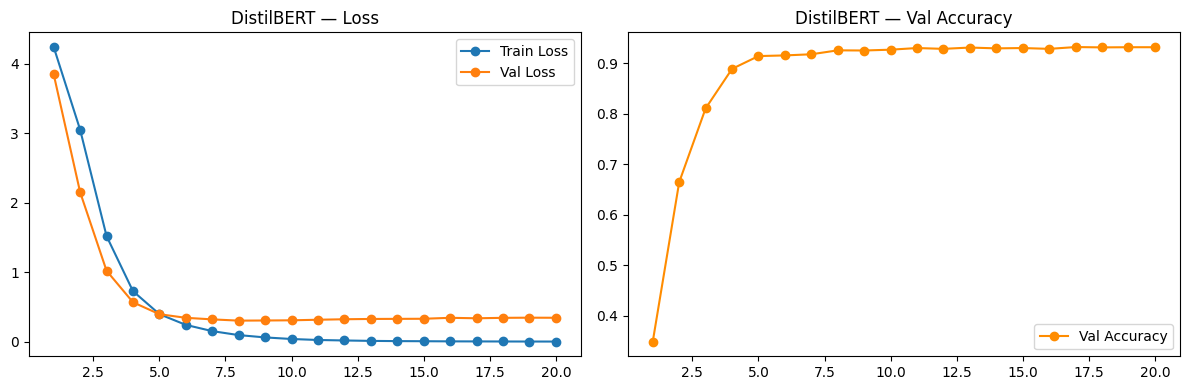

Guardado: results/bert_results.json


In [59]:
# Métricas finales BERT
bert_metrics = {
    'model':       'DistilBERT (fine-tuned)',
    'accuracy':    round(accuracy_score(best_labels_stored, best_preds), 4),
    'precision':   round(precision_score(best_labels_stored, best_preds, average='macro', zero_division=0), 4),
    'recall':      round(recall_score(best_labels_stored, best_preds, average='macro', zero_division=0), 4),
    'f1_macro':    round(f1_score(best_labels_stored, best_preds, average='macro', zero_division=0), 4),
    'f1_weighted': round(f1_score(best_labels_stored, best_preds, average='weighted', zero_division=0), 4),
}
for k, v in bert_metrics.items():
    if k != 'model': print(f'  {k:<15}: {v:.4f}')

# Curvas de entrenamiento
epochs_x = range(1, BERT_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs_x, train_losses, 'o-', label='Train Loss')
axes[0].plot(epochs_x, val_losses,   'o-', label='Val Loss')
axes[0].set_title('DistilBERT — Loss'); axes[0].legend()
axes[1].plot(epochs_x, val_accs, 'o-', color='darkorange', label='Val Accuracy')
axes[1].set_title('DistilBERT — Val Accuracy'); axes[1].legend()
plt.tight_layout()
plt.savefig('results/figures/bert_training_history.png', dpi=150)
plt.show()

with open('results/bert_results.json', 'w') as f:
    json.dump([bert_metrics], f, indent=2)
print('Guardado: results/bert_results.json')

# Guardar history de entrenamiento
with open('results/bert_history.json', 'w') as f:
    json.dump({'train_losses': train_losses,
               'val_losses':   val_losses,
               'val_accs':     val_accs}, f)

# Guardar predicciones
np.savez('results/bert_predictions.npz',
         preds=np.array(best_preds),
         labels=np.array(best_labels_stored))

---
## SECCIÓN 5 — Comparación de Resultados
Carga todos los resultados guardados y genera las visualizaciones comparativas.

In [86]:
import json, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

all_results = []
for fname in ['results/traditional_results.json',
              'results/lstm_results.json',
              'results/bert_results.json']:
    if os.path.exists(fname):
        with open(fname) as f:
            all_results.extend(json.load(f))

df_results = pd.DataFrame(all_results).set_index('model')

colors_map = {
    'Logistic Regression':     '#12326E',
    'SVM (LinearSVC)':         '#00594E',
    'Random Forest':           '#C09B57',
    'Bidirectional LSTM':      '#921832',
    'DistilBERT (fine-tuned)': '#5B2D8E',  # morado similar a tu paleta
}

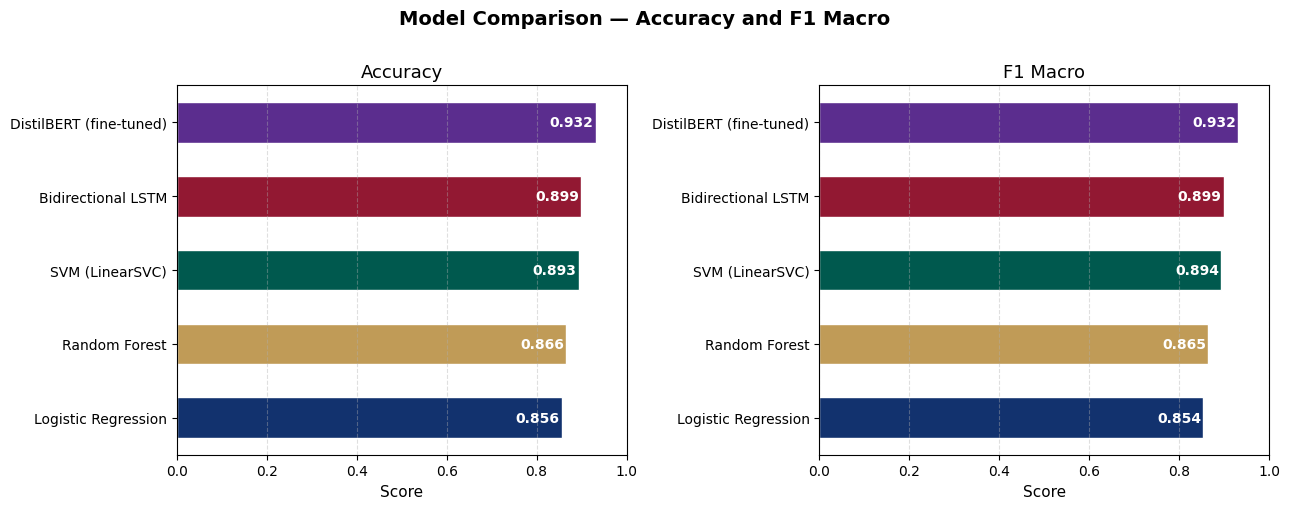

In [87]:
metrics = ['accuracy', 'f1_macro']
titles  = ['Accuracy', 'F1 Macro']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric, title in zip(axes, metrics, titles):
    vals   = df_results[metric].sort_values()
    colors = [colors_map.get(m, '#888780') for m in vals.index]
    bars   = ax.barh(vals.index, vals.values, color=colors, edgecolor='white', height=0.55)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_width() - 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', ha='right', fontsize=10, color='white', fontweight='bold')
    ax.set_xlim(0, 1)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Score', fontsize=11)
    ax.grid(True, axis='x', linestyle='--', alpha=0.4)

plt.suptitle('Model Comparison — Accuracy and F1 Macro', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('results/figures/comparison_accuracy_f1.png', dpi=150, bbox_inches='tight')
plt.show()

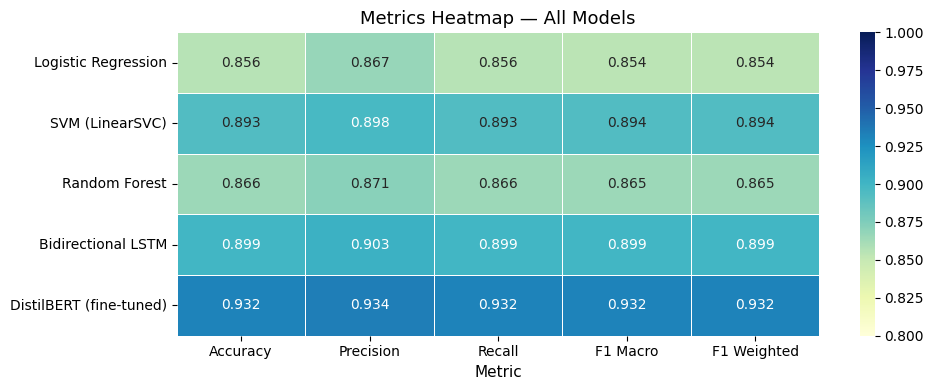

In [88]:
cols = ['accuracy', 'precision', 'recall', 'f1_macro', 'f1_weighted']

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(df_results[cols].astype(float), annot=True, fmt='.3f',
            cmap='YlGnBu', linewidths=0.5, vmin=0.8, vmax=1.0, ax=ax)
ax.set_title('Metrics Heatmap — All Models', fontsize=13)
ax.set_xlabel('Metric', fontsize=11)
ax.set_ylabel('')
ax.set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1 Macro', 'F1 Weighted'], fontsize=10)
plt.tight_layout()
plt.savefig('results/figures/heatmap_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

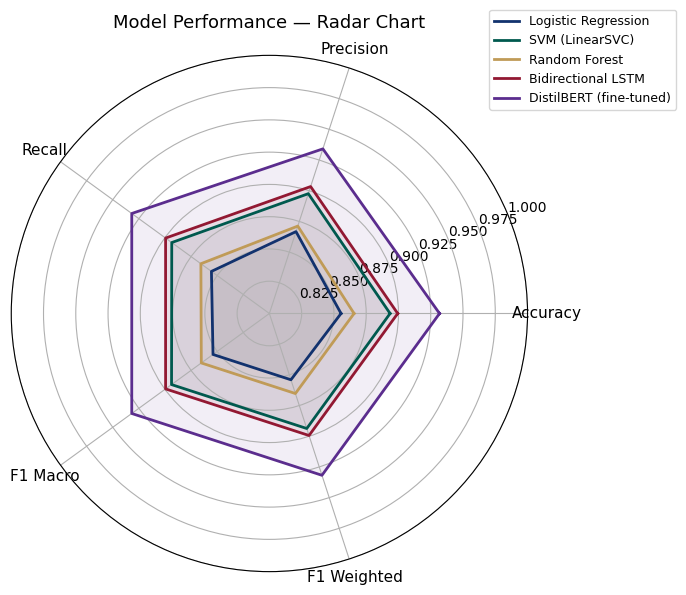

In [89]:
cols   = ['accuracy', 'precision', 'recall', 'f1_macro', 'f1_weighted']
labels = ['Accuracy', 'Precision', 'Recall', 'F1 Macro', 'F1 Weighted']
N      = len(cols)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist() + [0]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'polar': True})
for model_name, row in df_results.iterrows():
    values = row[cols].tolist() + [row[cols[0]]]
    ax.plot(angles, values, label=model_name,
            color=colors_map.get(model_name, '#888780'), linewidth=2)
    ax.fill(angles, values, alpha=0.08,
            color=colors_map.get(model_name, '#888780'))

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0.8, 1.0)
ax.set_title('Model Performance — Radar Chart', fontsize=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9)
plt.tight_layout()
plt.savefig('results/figures/radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

In [90]:
# Guardar tabla final
df_results.reset_index().to_csv('results/comparison_table.csv', index=False)
best = df_results['f1_macro'].idxmax()
print(f'Mejor modelo por F1 Macro: {best} ({df_results.loc[best, "f1_macro"]:.4f})')
print('Tabla guardada: results/comparison_table.csv')

Mejor modelo por F1 Macro: DistilBERT (fine-tuned) (0.9318)
Tabla guardada: results/comparison_table.csv


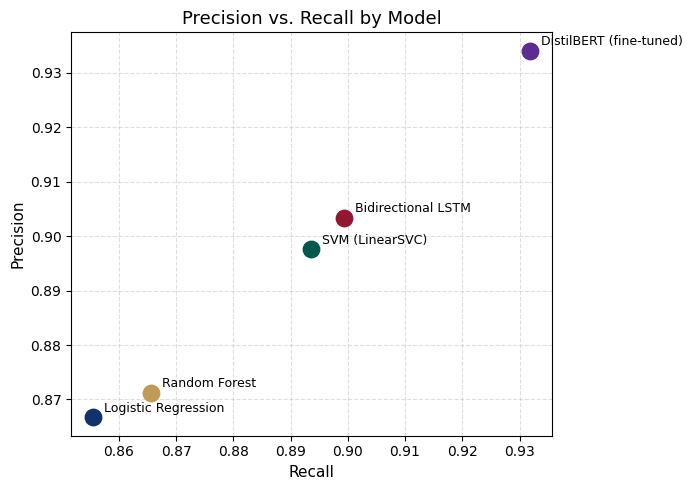

In [91]:
fig, ax = plt.subplots(figsize=(7, 5))
for model_name, row in df_results.iterrows():
    c = colors_map.get(model_name, '#888780')
    ax.scatter(row['recall'], row['precision'], color=c, s=140, zorder=5)
    ax.annotate(model_name, (row['recall'], row['precision']),
                textcoords="offset points", xytext=(8, 4), fontsize=9)

ax.set_xlabel('Recall', fontsize=11)
ax.set_ylabel('Precision', fontsize=11)
ax.set_title('Precision vs. Recall by Model', fontsize=13)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('results/figures/precision_recall_scatter.png', dpi=150)
plt.show()

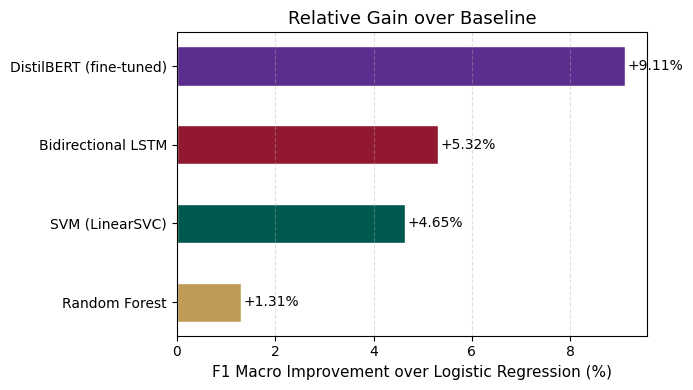

In [92]:
baseline_f1 = df_results.loc['Logistic Regression', 'f1_macro']
df_gain = df_results.drop('Logistic Regression').copy()
df_gain['gain_pct'] = (df_gain['f1_macro'] - baseline_f1) / baseline_f1 * 100
df_gain = df_gain.sort_values('gain_pct')

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(df_gain.index, df_gain['gain_pct'],
               color=[colors_map.get(m, '#888780') for m in df_gain.index],
               edgecolor='white', height=0.5)
for bar, val in zip(bars, df_gain['gain_pct']):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'+{val:.2f}%', va='center', fontsize=10)

ax.set_xlabel('F1 Macro Improvement over Logistic Regression (%)', fontsize=11)
ax.set_title('Relative Gain over Baseline', fontsize=13)
ax.grid(True, axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('results/figures/relative_gain_baseline.png', dpi=150)
plt.show()

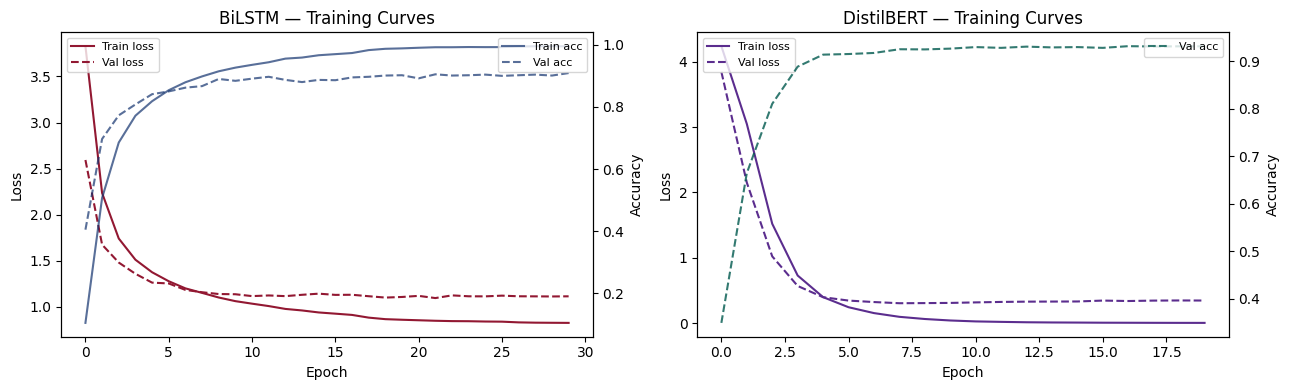

In [93]:
import torch

# BiLSTM — carga history desde archivo
with open('results/lstm_results.json') as f:
    lstm_data = json.load(f)
# El history lo guardamos aparte, verificamos si existe
if os.path.exists('results/lstm_history.json'):
    with open('results/lstm_history.json') as f:
        history = json.load(f)
else:
    print("⚠️  results/lstm_history.json no encontrado — corre la Sección 3 primero")
    history = None

# DistilBERT — carga desde archivo
if os.path.exists('results/bert_history.json'):
    with open('results/bert_history.json') as f:
        bert_history = json.load(f)
    train_losses = bert_history['train_losses']
    val_losses   = bert_history['val_losses']
    val_accs     = bert_history['val_accs']
else:
    print("⚠️  results/bert_history.json no encontrado — corre la Sección 4 primero")
    bert_history = None

if history and bert_history:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # BiLSTM
    axes[0].plot(history['loss'],     label='Train loss', color='#921832')
    axes[0].plot(history['val_loss'], label='Val loss',   color='#921832', linestyle='--')
    ax2 = axes[0].twinx()
    ax2.plot(history['accuracy'],     label='Train acc', color='#12326E', alpha=0.7)
    ax2.plot(history['val_accuracy'], label='Val acc',   color='#12326E', linestyle='--', alpha=0.7)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    ax2.set_ylabel('Accuracy')
    axes[0].set_title('BiLSTM — Training Curves', fontsize=12)
    axes[0].legend(loc='upper left', fontsize=8)
    ax2.legend(loc='upper right', fontsize=8)

    # DistilBERT
    axes[1].plot(train_losses, label='Train loss', color='#5B2D8E')
    axes[1].plot(val_losses,   label='Val loss',   color='#5B2D8E', linestyle='--')
    ax3 = axes[1].twinx()
    ax3.plot(val_accs, label='Val acc', color='#00594E', linestyle='--', alpha=0.8)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    ax3.set_ylabel('Accuracy')
    axes[1].set_title('DistilBERT — Training Curves', fontsize=12)
    axes[1].legend(loc='upper left', fontsize=8)
    ax3.legend(loc='upper right', fontsize=8)

    plt.tight_layout()
    plt.savefig('results/figures/training_curves.png', dpi=150)
    plt.show()

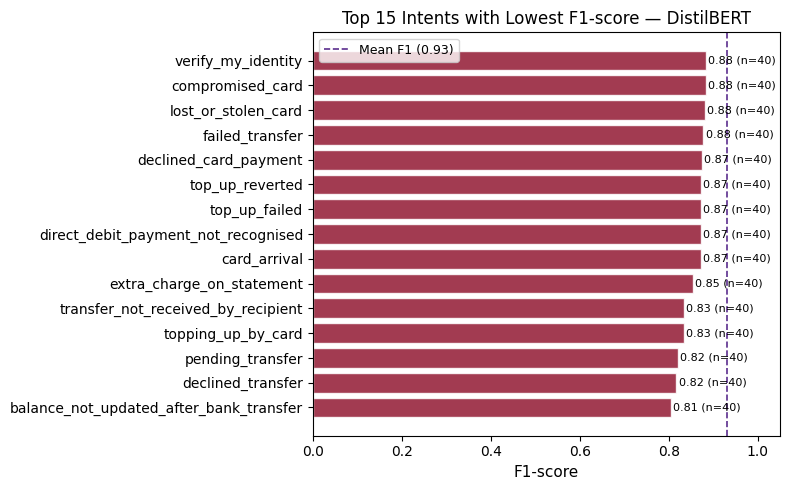

In [94]:
from sklearn.metrics import classification_report

# Carga label_names
with open('data/label_names.json') as f:
    label_names = json.load(f)

# Carga predicciones guardadas desde la Sección 4
if os.path.exists('results/bert_predictions.npz'):
    npz = np.load('results/bert_predictions.npz')
    best_preds         = npz['preds']
    best_labels_stored = npz['labels']
else:
    print("⚠️  results/bert_predictions.npz no encontrado — corre la Sección 4 primero")
    best_preds = None

if best_preds is not None:
    report    = classification_report(best_labels_stored, best_preds,
                                      target_names=label_names, output_dict=True)
    df_report = pd.DataFrame(report).T.iloc[:-3]
    df_worst  = df_report.nsmallest(15, 'f1-score')[['f1-score', 'support']]

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.barh(df_worst.index, df_worst['f1-score'],
                   color='#921832', alpha=0.85, edgecolor='white')
    for bar, (_, row) in zip(bars, df_worst.iterrows()):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                f"{row['f1-score']:.2f} (n={int(row['support'])})", va='center', fontsize=8)

    avg_f1 = df_report['f1-score'].mean()
    ax.axvline(x=avg_f1, color='#5B2D8E', linestyle='--', linewidth=1.2,
               label=f'Mean F1 ({avg_f1:.2f})')
    ax.set_xlabel('F1-score', fontsize=11)
    ax.set_title('Top 15 Intents with Lowest F1-score — DistilBERT', fontsize=12)
    ax.set_xlim(0, 1.05)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig('results/figures/worst_intents_f1.png', dpi=150)
    plt.show()

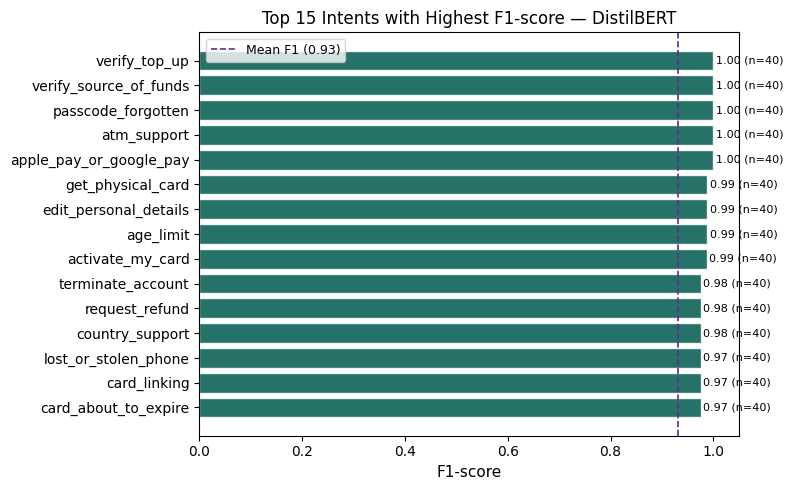

In [95]:
from sklearn.metrics import classification_report

with open('data/label_names.json') as f:
    label_names = json.load(f)

if os.path.exists('results/bert_predictions.npz'):
    npz = np.load('results/bert_predictions.npz')
    best_preds         = npz['preds']
    best_labels_stored = npz['labels']
else:
    print("⚠️  results/bert_predictions.npz no encontrado — corre la Sección 4 primero")
    best_preds = None

if best_preds is not None:
    report    = classification_report(best_labels_stored, best_preds,
                                      target_names=label_names, output_dict=True)
    df_report = pd.DataFrame(report).T.iloc[:-3]
    df_best = df_report.nlargest(15, 'f1-score')[['f1-score', 'support']].sort_values('f1-score')

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.barh(df_best.index, df_best['f1-score'],
                   color='#00594E', alpha=0.85, edgecolor='white')
    for bar, (_, row) in zip(bars, df_best.iterrows()):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                f"{row['f1-score']:.2f} (n={int(row['support'])})", va='center', fontsize=8)

    avg_f1 = df_report['f1-score'].mean()
    ax.axvline(x=avg_f1, color='#5B2D8E', linestyle='--', linewidth=1.2,
               label=f'Mean F1 ({avg_f1:.2f})')
    ax.set_xlabel('F1-score', fontsize=11)
    ax.set_title('Top 15 Intents with Highest F1-score — DistilBERT', fontsize=12)
    ax.set_xlim(0, 1.05)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig('results/figures/best_intents_f1.png', dpi=150)
    plt.show()

In [98]:
from torchviz import make_dot
x = torch.randint(0, VOCAB_SIZE, (1, MAX_LEN)).to(DEVICE_LSTM)
y = lstm_model(x)
make_dot(y, params=dict(lstm_model.named_parameters())).render("bilstm_arch", format="png")

'bilstm_arch.png'